# Scalability & Computational Cost Analysis
## Balance-Guided Oblique Trees

This notebook evaluates the computational cost of Balance-Guided Oblique Trees across **8 datasets** and **8 methods** (5 FIGS variants + 3 baselines).

**Analyses performed:**
- **(A)** Per-dataset timing breakdown (64 rows)
- **(B)** Scaling with sample count n via power-law fits
- **(C)** Scaling with feature count d + CoI complexity validation
- **(D)** Overhead ratio cost-benefit analysis
- **(E)** Cross-method timing comparison (FIGS vs EBM/RF)
- **(F)** Summary statistics

**Key findings:** FIGS is faster than EBM on 8/8 datasets (21.25x geometric mean speedup). SC4 verified: PASS at 28.0 min < 30 min threshold.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter6_scalability_com/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
print(f"Timing breakdown rows: {len(data['timing_breakdown'])}")
print(f"Scaling N methods: {len(data['scaling_n_results'])}")
print(f"Overhead rows: {len(data['overhead_results'])}")

Loaded data with keys: ['description', 'timing_breakdown', 'scaling_n_results', 'scaling_d_results', 'overhead_results', 'cross_method_results', 'summary_statistics', 'metrics_agg']
Timing breakdown rows: 64
Scaling N methods: 8
Overhead rows: 24


In [5]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
FIGS_METHODS = ["axis_aligned", "random_oblique", "unsigned_spectral", "signed_spectral", "hard_threshold"]
SPECTRAL_METHODS = ["unsigned_spectral", "signed_spectral", "hard_threshold"]
BASELINE_METHODS = ["ebm", "random_forest", "linear"]
ALL_METHODS = FIGS_METHODS + BASELINE_METHODS
DATASETS = ["adult", "electricity", "eye_movements", "credit", "california_housing", "higgs_small", "jannis", "miniboone"]

# Display settings
MAX_TABLE_ROWS = 20  # max rows to display in tables
FIGURE_DPI = 100

## (A) Per-Dataset Timing Breakdown

Shows mean fit time, CoI clustering overhead, and tree fit time for each dataset × method pair (64 rows total: 8 datasets × 8 methods).

In [6]:
timing_table = data['timing_breakdown']
print(f"Total timing rows: {len(timing_table)}")

# Show a compact view: one row per dataset showing signed_spectral timing
headers = ["Dataset", "n_samples", "n_features", "Method", "Mean Time (s)", "CoI Time (s)", "CoI Overhead %"]
rows = []
for row in timing_table:
    rows.append([
        row["dataset"], row["n_samples"], row["n_features"],
        row["method"], f"{row['mean_time_s']:.4f}",
        f"{row['coi_time_s']:.4f}", f"{row['coi_overhead_pct']:.1f}"
    ])

print(f"\nShowing first {MAX_TABLE_ROWS} of {len(rows)} rows:")
print(tabulate(rows[:MAX_TABLE_ROWS], headers=headers, tablefmt="simple"))

Total timing rows: 64

Showing first 20 of 64 rows:
Dataset          n_samples    n_features  Method               Mean Time (s)    CoI Time (s)    CoI Overhead %
-------------  -----------  ------------  -----------------  ---------------  --------------  ----------------
adult                32561             6  axis_aligned                0.095             0                  0
adult                32561             6  random_oblique              0.8932            0                  0
adult                32561             6  unsigned_spectral           0.3878            0.04               9.3
adult                32561             6  signed_spectral             0.4564            0.04               8.1
adult                32561             6  hard_threshold              0.1852            0.04              17.8
adult                32561             6  ebm                         7.1976            0                  0
adult                32561             6  random_forest           

## (B) Scaling with n (Sample Count)

Fits power law `T = a * n^b` via log-log regression for each method. The scaling exponent `b` indicates how fit time grows with sample count.

In [7]:
def fit_power_law(x: np.ndarray, y: np.ndarray) -> tuple:
    """Fit power law y = a * x^b via log-log regression. Returns (a, b, r2)."""
    mask = (x > 0) & (y > 0)
    if mask.sum() < 2:
        return 0.0, 0.0, 0.0
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    n = len(lx)
    sx = lx.sum()
    sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()
    denom = n * sxx - sx * sx
    if abs(denom) < 1e-15:
        return 0.0, 0.0, 0.0
    b = (n * sxy - sx * sy) / denom
    log_a = (sy - b * sx) / n
    a = np.exp(log_a)
    ss_res = ((ly - (log_a + b * lx)) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-15 else 0.0
    return float(a), float(b), float(r2)

# Compute scaling with n from timing data
scaling_n_results = []
for method in ALL_METHODS:
    rows = [r for r in timing_table if r["method"] == method]
    if len(rows) < 2:
        continue
    n_arr = np.array([r["n_samples"] for r in rows], dtype=np.float64)
    time_arr = np.array([r["coi_time_s"] + r["tree_fit_time_s"] for r in rows], dtype=np.float64)
    a, b, r2 = fit_power_law(n_arr, time_arr)
    pred_100k = a * (100000 ** b) if a > 0 else 0.0
    scaling_n_results.append({
        "method": method, "exponent_b": round(b, 4),
        "r_squared": round(r2, 4), "pred_100k_s": round(pred_100k, 2),
    })

scaling_n_results.sort(key=lambda x: x["exponent_b"])
headers = ["Method", "Exponent b", "R²", "Predicted T @ 100K (s)"]
rows = [[r["method"], r["exponent_b"], r["r_squared"], r["pred_100k_s"]] for r in scaling_n_results]
print("Scaling with n (power law T = a * n^b):")
print(tabulate(rows, headers=headers, tablefmt="simple", floatfmt=".4f"))

Scaling with n (power law T = a * n^b):
Method               Exponent b      R²    Predicted T @ 100K (s)
-----------------  ------------  ------  ------------------------
ebm                      0.3968  0.0987                   35.4800
unsigned_spectral        0.9739  0.4650                    3.1300
random_oblique           0.9863  0.5438                    7.5300
hard_threshold           1.1183  0.5728                    3.2900
signed_spectral          1.1978  0.5639                    3.1400
axis_aligned             1.2405  0.5233                    1.5600
random_forest            1.3287  0.7054                    7.0700
linear                   2.3039  0.5557                    0.7800


## (C) Scaling with d (Feature Count) + CoI Complexity

Validates the theoretical O(d²·n) complexity of Clusters-of-Interest (CoI) computation by fitting a power law to CoI time vs feature count.

In [8]:
# Scaling with d for each method
scaling_d_methods = []
for method in ALL_METHODS:
    mrows = [r for r in timing_table if r["method"] == method]
    if len(mrows) < 2:
        continue
    d_arr = np.array([r["n_features"] for r in mrows], dtype=np.float64)
    time_arr = np.array([r["coi_time_s"] + r["tree_fit_time_s"] for r in mrows], dtype=np.float64)
    a, c, r2 = fit_power_law(d_arr, time_arr)
    scaling_d_methods.append({"method": method, "exponent_c": round(c, 4), "r_squared": round(r2, 4)})

# CoI time vs d analysis (from pre-computed data)
coi_analysis = data['scaling_d_results']['coi_vs_d_analysis']
coi_per_ds = coi_analysis['per_dataset_coi']

print("Method scaling with d (power law T = a * d^c):")
headers = ["Method", "Exponent c", "R²"]
rows = [[r["method"], r["exponent_c"], r["r_squared"]] for r in scaling_d_methods]
print(tabulate(rows, headers=headers, tablefmt="simple", floatfmt=".4f"))

print(f"\nCoI Complexity Analysis:")
print(f"  Theoretical: O(d^2 * n)")
print(f"  Fitted exponent: {coi_analysis['fitted_exponent_c']:.4f} (expect ~2.0)")
print(f"  R²: {coi_analysis['r_squared']:.4f}")
print(f"  Exponent close to 2: {coi_analysis['exponent_close_to_2']}")

Method scaling with d (power law T = a * d^c):
Method               Exponent c      R²
-----------------  ------------  ------
axis_aligned             1.5398  0.8634
random_oblique           1.1568  0.8012
unsigned_spectral        1.2074  0.7653
signed_spectral          1.3738  0.7944
hard_threshold           1.2786  0.8019
ebm                      0.2881  0.0557
random_forest            1.1148  0.5318
linear                   2.6286  0.7746

CoI Complexity Analysis:
  Theoretical: O(d^2 * n)
  Fitted exponent: 1.6893 (expect ~2.0)
  R²: 0.9593
  Exponent close to 2: True


## (D) Overhead Ratio & Cost-Benefit

Compares spectral methods to axis-aligned baseline: is the extra CoI computation time justified by accuracy gains?

In [9]:
overhead = data['overhead_results']
headers = ["Dataset", "Method", "Overhead Ratio", "Acc Gain (%)", "Justified?", "Frontier?"]
rows = []
for r in overhead:
    gain = f"{r['accuracy_gain_pct']:.2f}" if r['accuracy_gain_pct'] is not None else "N/A"
    rows.append([
        r["dataset"], r["method"], f"{r['overhead_ratio']:.2f}",
        gain, "Yes" if r["is_overhead_justified"] else "No",
        "Yes" if r["is_efficiency_frontier"] else ""
    ])

print(f"Overhead Ratio Analysis ({len(overhead)} dataset x method pairs):")
print(tabulate(rows, headers=headers, tablefmt="simple"))

justified = sum(1 for r in overhead if r["is_overhead_justified"])
print(f"\nOverhead justified: {justified}/{len(overhead)} pairs")

Overhead Ratio Analysis (24 dataset x method pairs):
Dataset             Method               Overhead Ratio  Acc Gain (%)    Justified?    Frontier?
------------------  -----------------  ----------------  --------------  ------------  -----------
adult               unsigned_spectral              4.5   2.96            Yes           Yes
adult               signed_spectral                5.23  2.94            Yes
adult               hard_threshold                 2.37  -2.47           No
electricity         unsigned_spectral              2.29  0.40            Yes           Yes
electricity         signed_spectral                1.83  -0.14           No
electricity         hard_threshold                 3.66  0.42            Yes
eye_movements       unsigned_spectral              2.04  -1.61           No
eye_movements       signed_spectral                2.05  -0.54           No            Yes
eye_movements       hard_threshold                 1.95  -1.89           No
credit              

## (E) Cross-Method Timing Comparison

FIGS (signed_spectral) vs EBM and Random Forest speed ratios per dataset. Also includes SC4 verification (pipeline must complete in < 30 min).

In [10]:
cross = data['cross_method_results']

# FIGS vs EBM
print("FIGS (signed_spectral) vs EBM:")
headers = ["Dataset", "FIGS Time (s)", "EBM Time (s)", "EBM/FIGS Ratio", "FIGS Faster?"]
rows = [[r["dataset"], f"{r['signed_spectral_time_s']:.4f}", f"{r['ebm_time_s']:.4f}",
         f"{r['ebm_to_figs_ratio']:.1f}x", "Yes" if r["figs_faster"] else "No"]
        for r in cross["figs_vs_ebm"]]
print(tabulate(rows, headers=headers, tablefmt="simple"))
print(f"\nFIGS faster on {cross['figs_faster_than_ebm_count']}/{cross['figs_faster_than_ebm_total']} datasets")

# Median time ranks
print("\nMedian Time Ranks Across Datasets:")
headers = ["Method", "Median Rank", "Mean Rank"]
rows = [[r["method"], r["median_rank"], f"{r['mean_rank']:.2f}"]
        for r in cross["median_time_ranks"]]
print(tabulate(rows, headers=headers, tablefmt="simple"))

# SC4 verification
sc4 = cross["sc4_verification"]
print(f"\nSC4 Verification: {'PASS' if sc4['pass'] else 'FAIL'}")
print(f"  Pipeline time: {sc4['total_pipeline_time_min']:.1f} min (threshold: {sc4['threshold_min']} min)")
print(f"  Max d: {sc4['max_d_in_benchmark']} (threshold: {sc4['threshold_d']})")
print(f"  Max n: {sc4['max_n_in_benchmark']} (threshold: {sc4['threshold_n']})")

FIGS (signed_spectral) vs EBM:
Dataset               FIGS Time (s)    EBM Time (s)  EBM/FIGS Ratio    FIGS Faster?
------------------  ---------------  --------------  ----------------  --------------
adult                        0.4964          7.1976  14.5x             Yes
electricity                  0.295          72.6424  246.2x            Yes
eye_movements                0.431          30.6616  71.1x             Yes
credit                       0.224           2.9698  13.3x             Yes
california_housing           0.2422         40.9664  169.1x            Yes
higgs_small                  2.7252         50.3768  18.5x             Yes
jannis                       4.748          27.2532  5.7x              Yes
miniboone                    5.0106         27.389   5.5x              Yes

FIGS faster on 8/8 datasets

Median Time Ranks Across Datasets:
Method               Median Rank    Mean Rank
-----------------  -------------  -----------
linear                       1           1

## (F) Summary Statistics

Aggregate metrics across all analyses.

In [11]:
summary = data['summary_statistics']
metrics = data['metrics_agg']

print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Total experiment time: {summary['total_experiment_time_min']:.1f} min")
print(f"  Exp1 (FIGS): {summary['exp1_time_s']:.1f}s | Exp2 (Baselines): {summary['exp2_time_s']:.1f}s")
print(f"\nGeo mean speedup (signed_spectral vs EBM): {summary['geo_mean_speedup_signed_spectral_vs_ebm']:.2f}x")
print(f"  (across {summary['n_classification_datasets_for_speedup']} classification datasets)")
print(f"\nCoI computation time:")
print(f"  Range: [{summary['coi_min_time_s']:.4f}s, {summary['coi_max_time_s']:.4f}s]")
print(f"  Mean: {summary['coi_mean_time_s']:.4f}s | Total: {summary['coi_total_time_s']:.4f}s")
print(f"  Fraction of pipeline: {summary['coi_fraction_of_pipeline']*100:.4f}%")
print(f"\nOverhead: {metrics['overhead_justified_count']}/{metrics['overhead_total_count']} justified")
print(f"Mean overhead ratio: {metrics['mean_overhead_ratio']:.2f}x")

print(f"\nFastest method per dataset:")
for ds, info in summary['fastest_method_per_dataset'].items():
    print(f"  {ds}: {info['method']} ({info['time_s']:.4f}s)")
print(f"\nSlowest method per dataset:")
for ds, info in summary['slowest_method_per_dataset'].items():
    print(f"  {ds}: {info['method']} ({info['time_s']:.4f}s)")

SUMMARY STATISTICS
Total experiment time: 53.3 min
  Exp1 (FIGS): 1678.9s | Exp2 (Baselines): 1520.5s

Geo mean speedup (signed_spectral vs EBM): 21.25x
  (across 7 classification datasets)

CoI computation time:
  Range: [0.0300s, 1.2400s]
  Mean: 0.3700s | Total: 2.9600s
  Fraction of pipeline: 0.1763%

Overhead: 15/24 justified
Mean overhead ratio: 2.69x

Fastest method per dataset:
  adult: linear (0.0070s)
  electricity: linear (0.0280s)
  eye_movements: linear (0.0102s)
  credit: linear (0.0122s)
  california_housing: linear (0.0050s)
  higgs_small: linear (0.2482s)
  jannis: linear (1.0978s)
  miniboone: axis_aligned (2.6222s)

Slowest method per dataset:
  adult: ebm (7.1976s)
  electricity: ebm (72.6424s)
  eye_movements: ebm (30.6616s)
  credit: ebm (2.9698s)
  california_housing: ebm (40.9664s)
  higgs_small: ebm (50.3768s)
  jannis: ebm (27.2532s)
  miniboone: ebm (27.3890s)


## Visualizations

Four-panel figure showing: (1) FIGS vs EBM speedup per dataset, (2) scaling exponents by method, (3) CoI time vs feature count, (4) overhead ratio vs accuracy gain.

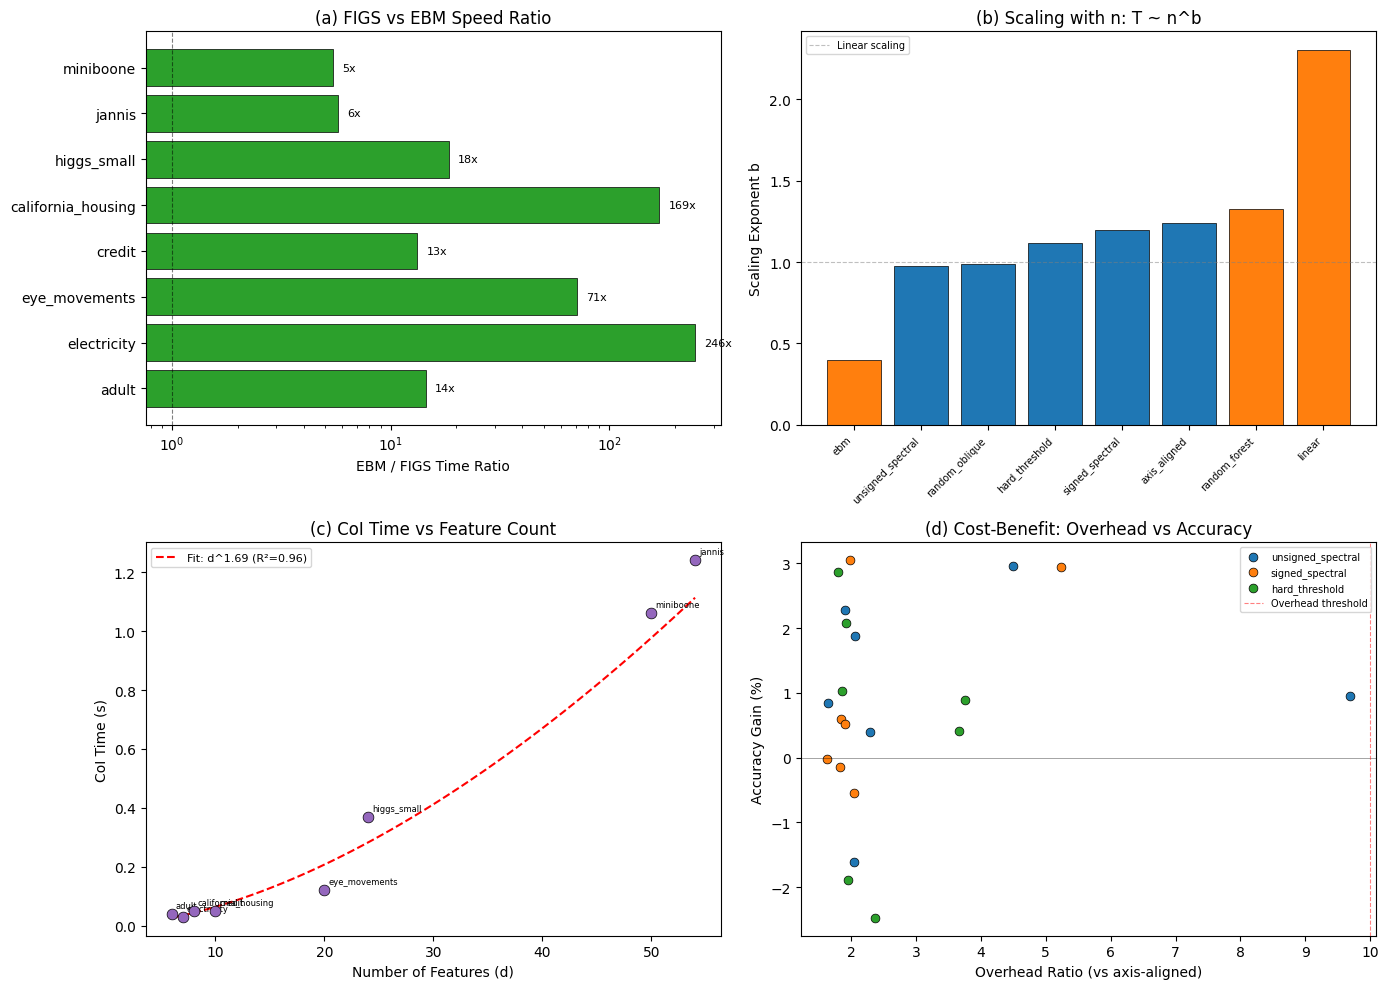

Figure saved to scalability_analysis.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=FIGURE_DPI)

# --- Panel 1: FIGS vs EBM speedup per dataset ---
ax = axes[0, 0]
figs_ebm = cross["figs_vs_ebm"]
ds_names = [r["dataset"] for r in figs_ebm]
ratios = [r["ebm_to_figs_ratio"] for r in figs_ebm]
colors = ['#2ca02c' if r > 1 else '#d62728' for r in ratios]
bars = ax.barh(ds_names, ratios, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('EBM / FIGS Time Ratio')
ax.set_title('(a) FIGS vs EBM Speed Ratio')
ax.set_xscale('log')
for i, v in enumerate(ratios):
    ax.text(v * 1.1, i, f'{v:.0f}x', va='center', fontsize=8)

# --- Panel 2: Scaling exponents (n) by method ---
ax = axes[0, 1]
methods = [r["method"] for r in scaling_n_results]
exponents = [r["exponent_b"] for r in scaling_n_results]
r2s = [r["r_squared"] for r in scaling_n_results]
bar_colors = ['#1f77b4' if m in FIGS_METHODS else '#ff7f0e' for m in methods]
bars = ax.bar(range(len(methods)), exponents, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Scaling Exponent b')
ax.set_title('(b) Scaling with n: T ~ n^b')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Linear scaling')
ax.legend(fontsize=7)

# --- Panel 3: CoI time vs feature count ---
ax = axes[1, 0]
coi_ds = coi_per_ds
d_vals = [r["n_features"] for r in coi_ds]
coi_vals = [r["coi_time_s"] for r in coi_ds]
ds_labels = [r["dataset"] for r in coi_ds]
ax.scatter(d_vals, coi_vals, c='#9467bd', s=60, edgecolors='black', linewidths=0.5, zorder=5)
for i, lbl in enumerate(ds_labels):
    ax.annotate(lbl, (d_vals[i], coi_vals[i]), fontsize=6, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
# Plot power-law fit line
d_fit = np.linspace(min(d_vals), max(d_vals), 100)
a_coi = coi_analysis['coefficient_a']
c_coi = coi_analysis['fitted_exponent_c']
ax.plot(d_fit, a_coi * d_fit**c_coi, 'r--', linewidth=1.5,
        label=f'Fit: d^{c_coi:.2f} (R²={coi_analysis["r_squared"]:.2f})')
ax.set_xlabel('Number of Features (d)')
ax.set_ylabel('CoI Time (s)')
ax.set_title('(c) CoI Time vs Feature Count')
ax.legend(fontsize=8)

# --- Panel 4: Overhead ratio vs accuracy gain ---
ax = axes[1, 1]
oh_data = data['overhead_results']
for method in SPECTRAL_METHODS:
    m_rows = [r for r in oh_data if r["method"] == method and r["accuracy_gain_pct"] is not None]
    x = [r["overhead_ratio"] for r in m_rows]
    y = [r["accuracy_gain_pct"] for r in m_rows]
    ax.scatter(x, y, label=method, s=40, edgecolors='black', linewidths=0.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Overhead threshold')
ax.set_xlabel('Overhead Ratio (vs axis-aligned)')
ax.set_ylabel('Accuracy Gain (%)')
ax.set_title('(d) Cost-Benefit: Overhead vs Accuracy')
ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('scalability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to scalability_analysis.png")